# Testing different regression methods

In [82]:
here::i_am("rna_atac/dimensionality_reduction/WNN.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 24

# Multi core using future - built in to seurat
plan("multicore", workers = 24)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [83]:
args = list()
# ATAC
args$atac_metadata = file.path(io$basedir, 'results/atac/archR/qc/sample_metadata_update_PeakClusters.txt.gz')
args$atac_lsi = file.path(io$basedir, 'processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds')
# RNA
args$rna_metadata = file.path(io$basedir, 'results/rna/doublet_detection/sample_metadata_after_doublets.txt.gz')
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')
args$rna_nfeatures = 4000
args$vars_to_regress = c("nFeature_RNA", "nCount_RNA", "mitochondrial_percent_RNA", "ribosomal_percent_RNA")
args$rna_npcs = 35
# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/wnn/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [84]:
##########################
## Load sample metadata ##
##########################

metadata_atac <- fread(args$atac_metadata) %>%
  .[pass_atacQC==TRUE & doublet_call==FALSE | pass_atacQC==TRUE & is.na(doublet_call)] %>% 
  .[,exp := str_replace_all(sample, opts$sample2exp)]

metadata_rna <- fread(args$rna_metadata) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE] %>% 
  .[,exp := str_replace_all(sample, opts$sample2exp)]

### RNA

In [72]:
RegressOutMatrix <- function(mtx, covariates = NULL, features_idx = NULL, verbose = TRUE) {
  
  # Check features_idx
  if (is.null(features_idx)) {
    features_idx <- 1:nrow(mtx)
  }
  if (is.character(features_idx)) {
    features_idx <- intersect(features_idx, rownames(mtx))
    if (length(features_idx) == 0) {
      stop("Cannot use features that are beyond the scope of mtx")
    }
  } else if (max(features_idx) > nrow(mtx)) {
    stop("Cannot use features that are beyond the scope of mtx")
  }
  
  # Check dataset dimensions
  if (nrow(covariates) != ncol(mtx)) {
    stop("Uneven number of cells between latent data and expression data")
  }
  
  # Subset
  mtx <- mtx[features_idx,]
  mtx.dimnames <- dimnames(mtx)
  
  # Create formula for regression
  vars.to.regress <- colnames(covariates)
  fmla <- paste('GENE ~', paste(vars.to.regress, collapse = '+')) %>% as.formula

  # In this code, we'll repeatedly regress different Y against the same X
  # (covariates) in order to calculate residuals.  Rather that repeatedly
  # call lm to do this, we'll avoid recalculating the QR decomposition for the
  # covariates matrix each time by reusing it after calculating it once
  regression.mat <- cbind(covariates, mtx[1,])
  colnames(regression.mat) <- c(colnames(covariates), "GENE")
  qr <- lm(fmla, data = regression.mat, qr = TRUE)$qr
  rm(regression.mat)

  # Make results matrix
  data.resid <- matrix(
    nrow = nrow(mtx),
    ncol = ncol(mtx)
  )

  if (verbose) pb <- txtProgressBar(char = '=', style = 3, file = stderr())

  # Extract residuals from each feature by using the pre-computed QR decomposition
  data.resid = mclapply(1:length(features_idx), function(i){
    regression.mat <- cbind(covariates, mtx[features_idx[i], ])
    colnames(regression.mat) <- c(vars.to.regress, 'GENE')
    regression.mat <- qr.resid(qr = qr, y = mtx[features_idx[i],])  # The function qr.resid returns the residuals when fitting y to the matrix with QR decomposition.
    return(regression.mat)
    if (verbose) {
      setTxtProgressBar(pb = pb, value = i / length(features_idx))
    }
  }, mc.cores=16)
  data.resid = do.call('rbind', data.resid)  

  if (verbose) close(con = pb)

  dimnames(data.resid) <- mtx.dimnames
  
  return(data.resid)
}

In [21]:
##############################
## Load RNA expression data ##
##############################

rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = metadata_rna$cell)

# Add sample metadata to the colData of the SingleCellExperiment
colData(rna.sce) <- metadata_rna %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(rna.sce),] %>% DataFrame()

# Filter features manually
rna.sce <- rna.sce[grep("*Rik|^Gm|^Mt-|^Rps|^Rpl|^Olfr",rownames(rna.sce), invert=T),]

# Feature selection
rna_features <- modelGeneVar(rna.sce, block=metadata_rna$exp, BPPARAM = BPPARAM ) %>% as.data.table(keep.rownames = T) %>%
  setnames("rn","gene") %>%
  .[mean>=0.001] %>% setorder(FDR) %>% head(args$rna_nfeatures) %>% .$gene

# Fetch matrix
rna.mtx <- assay(rna.sce[rna_features,],"logcounts") %>% round(2)
dim(rna.mtx)

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


[1]  4000 38346

In [81]:
# Regress out variables 
logcounts_regressed.mtx <- RegressOutMatrix(
    mtx = logcounts(rna.sce),
    covariates = metadata_rna[,args$vars_to_regress,with=F]
  )

In [88]:
tmp = logcounts(rna.sce)

In [91]:
logcounts(rna.sce) = logcounts_regressed.mtx

# Feature selection & PCA based on regressed log counts


In [95]:
# Feature selection based on regressed log counts
rna_features <- modelGeneVar(rna.sce, block=metadata_rna$exp) %>% as.data.table(keep.rownames = T) %>%
  setnames("rn","gene") %>%
  .[mean>=0.001] %>% setorder(FDR) %>% head(args$rna_nfeatures) %>% .$gene

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [98]:
rna.seurat = as.Seurat(rna.sce)

In [101]:
##################################
## RNA dimensionality reduction ##
##################################
rna.seurat <- ScaleData(rna.seurat, 
                    features = rna_features,
                    #vars.to.regress = args$vars_to_regress,
                    verbose = FALSE)

rna.seurat <- RunPCA(rna.seurat, features = rna_features, npcs = args$rna_npcs, verbose = FALSE)

# Save PCA coordinates
rna_pca.dt <- rna.seurat@reductions[["pca"]]@cell.embeddings %>% round(3) %>% as.data.table(keep.rownames = T) %>% setnames("rn","cell")

Warning message:
“Hmm... 3 active multicore processes were detected, but without any active multicore futures (it is not clear by what mechanism they were created). Because of this, the 'future' package do not know how to resolve/collect them and will therefore treat them as they do not exist.”


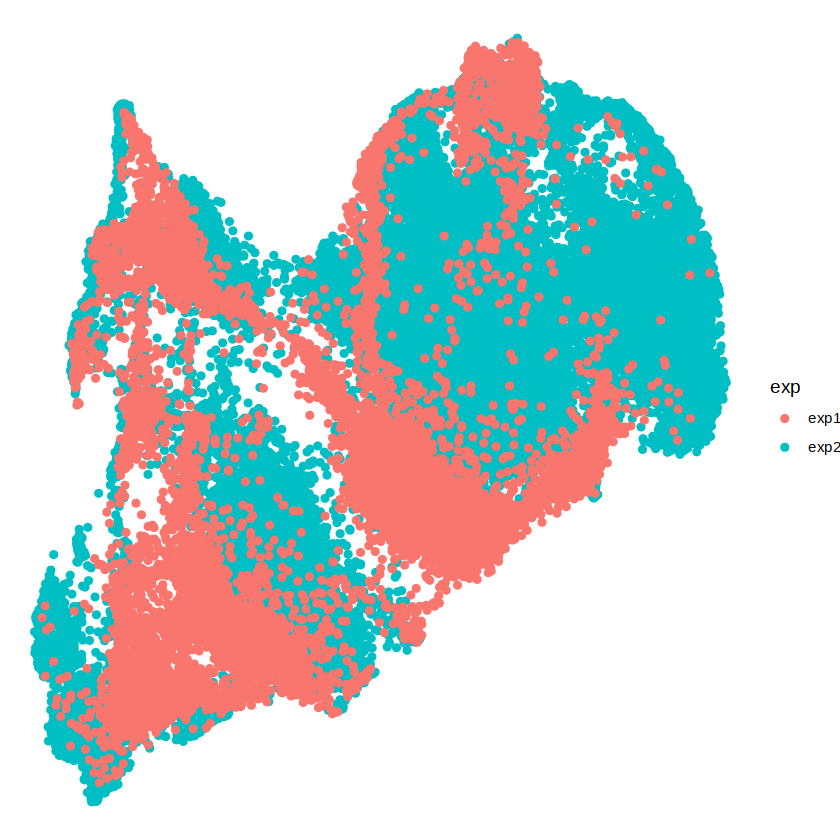

In [102]:
rna.seurat <- RunUMAP(rna.seurat, 
  dims = 1:args$rna_npcs,
  reduction = "pca",
  n.neighbors = 25,
  min.dist = 0.3,
  verbose=FALSE
)

# Fetch UMAP coordinates
umap.dt <- rna.seurat@reductions[["umap"]]@cell.embeddings %>% round(3) %>% as.data.table %>% 
  .[,cell:=colnames(rna.seurat)] %>%
  setnames(c("UMAP1","UMAP2","cell")) %>% 
  .[,c("cell","UMAP1","UMAP2")] %>%
  merge(.,metadata_rna, by='cell')

# Plot umap
ggplot(umap.dt, aes(UMAP1, UMAP2, col=exp)) + 
    geom_point(size=0.5) + 
    theme_void()


# Feature selection regressed log counts & PCA on original logcounts with regression while scaling


In [105]:
# Feature selection based on regressed log counts
rna_features <- modelGeneVar(rna.sce, block=metadata_rna$exp) %>% as.data.table(keep.rownames = T) %>%
  setnames("rn","gene") %>%
  .[mean>=0.001] %>% setorder(FDR) %>% head(args$rna_nfeatures) %>% .$gene

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [106]:
logcounts(rna.sce) = tmp

In [98]:
rna.seurat = as.Seurat(rna.sce)

In [107]:
##################################
## RNA dimensionality reduction ##
##################################
rna.seurat <- ScaleData(rna.seurat, 
                    features = rna_features,
                    vars.to.regress = args$vars_to_regress,
                    verbose = FALSE)

rna.seurat <- RunPCA(rna.seurat, features = rna_features, npcs = args$rna_npcs, verbose = FALSE)

# Save PCA coordinates
rna_pca.dt <- rna.seurat@reductions[["pca"]]@cell.embeddings %>% round(3) %>% as.data.table(keep.rownames = T) %>% setnames("rn","cell")

Warning message:
“Hmm... 3 active multicore processes were detected, but without any active multicore futures (it is not clear by what mechanism they were created). Because of this, the 'future' package do not know how to resolve/collect them and will therefore treat them as they do not exist.”
Warning message:
“Hmm... 3 active multicore processes were detected, but without any active multicore futures (it is not clear by what mechanism they were created). Because of this, the 'future' package do not know how to resolve/collect them and will therefore treat them as they do not exist.”


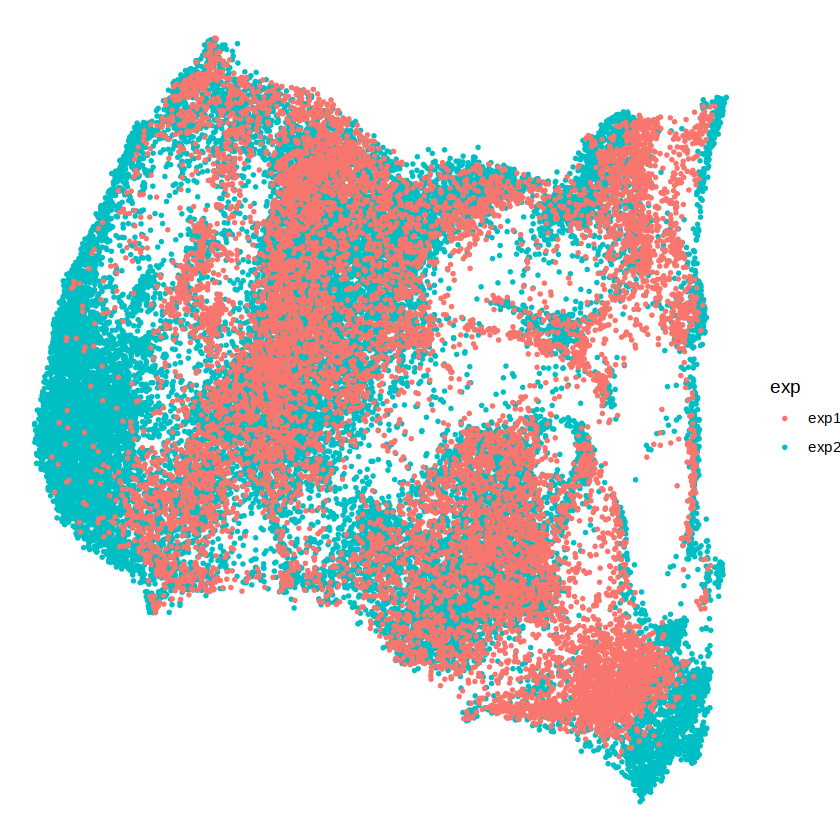

In [108]:
rna.seurat <- RunUMAP(rna.seurat, 
  dims = 1:args$rna_npcs,
  reduction = "pca",
  n.neighbors = 25,
  min.dist = 0.3,
  verbose=FALSE
)

# Fetch UMAP coordinates
umap.dt <- rna.seurat@reductions[["umap"]]@cell.embeddings %>% round(3) %>% as.data.table %>% 
  .[,cell:=colnames(rna.seurat)] %>%
  setnames(c("UMAP1","UMAP2","cell")) %>% 
  .[,c("cell","UMAP1","UMAP2")] %>%
  merge(.,metadata_rna, by='cell')

# Plot umap
ggplot(umap.dt, aes(UMAP1, UMAP2, col=exp)) + 
    geom_point(size=0.5) + 
    theme_void()


# Feature selection regressed log counts without block & PCA on original logcounts with regression while scaling


In [140]:
logcounts(rna.sce) = logcounts_regressed.mtx #logcounts_regressed.mtx

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


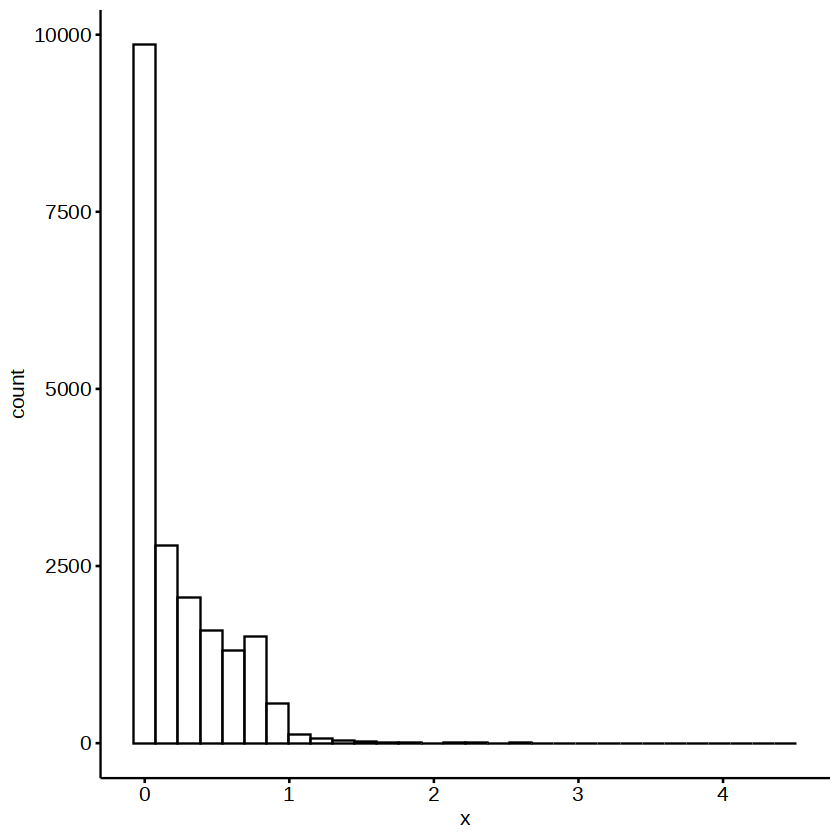

In [146]:
gghistogram(rowVars(logcounts(rna.sce)))

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


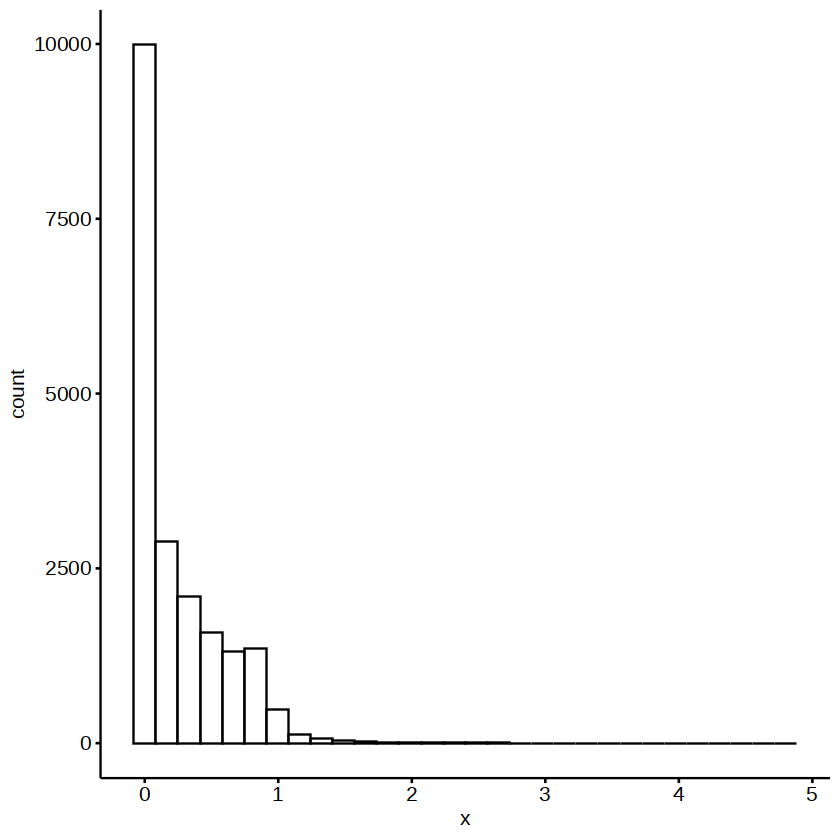

In [147]:
gghistogram(rowVars(tmp))

In [145]:
# Feature selection based on regressed log counts
rna_features <- modelGeneVar(rna.sce, block=metadata_rna[,a:='a']$a) #%>% as.data.table(keep.rownames = T) %>%
  # setnames("rn","gene") %>%
  # .[mean>=0.001] %>% setorder(FDR) %>% head(args$rna_nfeatures) %>% .$gene

ERROR: Error in density.default(x, adjust = adjust, from = min(x), to = max(x)): need at least 2 points to select a bandwidth automatically


In [143]:
head(rna_features, 100)

[1] "Ube2w"    "Klf7"     "Dis3l2"   "Eif4e2"   "Tsen15"   "Lin9"    
  [7] "Dhtkd1"   "Ddx31"    "Tank"     "Atf2"     "Meis2"    "Tmem230" 
 [13] "Pex2"     "Efna4"    "Sf3b4"    "Cept1"    "Camk2d"   "Ube2d3"  
 [19] "Eif4e"    "Bcl10"    "Plag1"    "Usp45"    "Pnisr"    "Smu1"    
 [25] "Ugcg"     "Prpf38a"  "Faf1"     "Efcab14"  "Ptprf"    "Ctps"    
 [31] "Tmem50a"  "Clcn6"    "Tardbp"   "Gnb1"     "Crot"     "Klhl7"   
 [37] "Ube3c"    "Hadha"    "Maea"     "Polr2b"   "Adamts3"  "Mtf2"    
 [43] "Naa25"    "Atp2a2"   "Zcchc8"   "Hibadh"   "Foxp1"    "Ncapd2"  
 [49] "Tm2d3"    "Mki67"    "Itfg1"    "Cwf19l2"  "Cep164"   "Cadm1"   
 [55] "Cul5"     "Adpgk"    "Rbpms2"   "Tmod3"    "Gclc"     "Clstn2"  
 [61] "Manf"     "Amd1"     "Gpx4"     "Atp2b1"   "Slc1a4"   "Slu7"    
 [67] "Ctc1"     "Blmh"     "Lhx1"     "Bcas3"    "Pitpnc1"  "Aspscr1" 
 [73] "Dock4"    "Ralgapa1" "Sav1"     "Rhoj"     "Rdh11"    "Cox16"   
 [79] "Mark3"    "Zmynd11"  "Prpf4b"   "Fars2"    "Zfp346"   "Ssbp2"   
 [85] "Col4a3bp" "Map1b"    "Cdk7"     "Cwc27"    "Pde4d"    "Adk"     
 [91] "Mrpl52"   "Dpysl2"   "Med4"     "Tdrd3"    "Rad21"    "Tcf20"   
 [97] "Nup50"    "Arid2"    "Larp4"    "Pcbp2"

In [ ]:
logcounts(rna.sce) = tmp

In [ ]:
rna.seurat = as.Seurat(rna.sce)

In [ ]:
##################################
## RNA dimensionality reduction ##
##################################
rna.seurat <- ScaleData(rna.seurat, 
                    features = rna_features,
                    vars.to.regress = args$vars_to_regress,
                    verbose = FALSE)

rna.seurat <- RunPCA(rna.seurat, features = rna_features, npcs = args$rna_npcs, verbose = FALSE)

# Save PCA coordinates
rna_pca.dt <- rna.seurat@reductions[["pca"]]@cell.embeddings %>% round(3) %>% as.data.table(keep.rownames = T) %>% setnames("rn","cell")

In [ ]:
rna.seurat <- RunUMAP(rna.seurat, 
  dims = 1:args$rna_npcs,
  reduction = "pca",
  n.neighbors = 25,
  min.dist = 0.3,
  verbose=FALSE
)

# Fetch UMAP coordinates
umap.dt <- rna.seurat@reductions[["umap"]]@cell.embeddings %>% round(3) %>% as.data.table %>% 
  .[,cell:=colnames(rna.seurat)] %>%
  setnames(c("UMAP1","UMAP2","cell")) %>% 
  .[,c("cell","UMAP1","UMAP2")] %>%
  merge(.,metadata_rna, by='cell')

# Plot umap
ggplot(umap.dt, aes(UMAP1, UMAP2, col=exp)) + 
    geom_point(size=0.5) + 
    theme_void()


# Feature selection on original log counts & PCA on original logcounts with regression while scaling


In [109]:
# Feature selection based on regressed log counts
logcounts(rna.sce) = tmp
rna_features <- modelGeneVar(rna.sce, block=metadata_rna$exp) %>% as.data.table(keep.rownames = T) %>%
  setnames("rn","gene") %>%
  .[mean>=0.001] %>% setorder(FDR) %>% head(args$rna_nfeatures) %>% .$gene

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [110]:
logcounts(rna.sce) = tmp

In [111]:
rna.seurat = as.Seurat(rna.sce)

In [112]:
##################################
## RNA dimensionality reduction ##
##################################
rna.seurat <- ScaleData(rna.seurat, 
                    features = rna_features,
                    vars.to.regress = args$vars_to_regress,
                    verbose = FALSE)

rna.seurat <- RunPCA(rna.seurat, features = rna_features, npcs = args$rna_npcs, verbose = FALSE)

# Save PCA coordinates
rna_pca.dt <- rna.seurat@reductions[["pca"]]@cell.embeddings %>% round(3) %>% as.data.table(keep.rownames = T) %>% setnames("rn","cell")

Warning message:
“Hmm... 3 active multicore processes were detected, but without any active multicore futures (it is not clear by what mechanism they were created). Because of this, the 'future' package do not know how to resolve/collect them and will therefore treat them as they do not exist.”
Warning message:
“Hmm... 3 active multicore processes were detected, but without any active multicore futures (it is not clear by what mechanism they were created). Because of this, the 'future' package do not know how to resolve/collect them and will therefore treat them as they do not exist.”


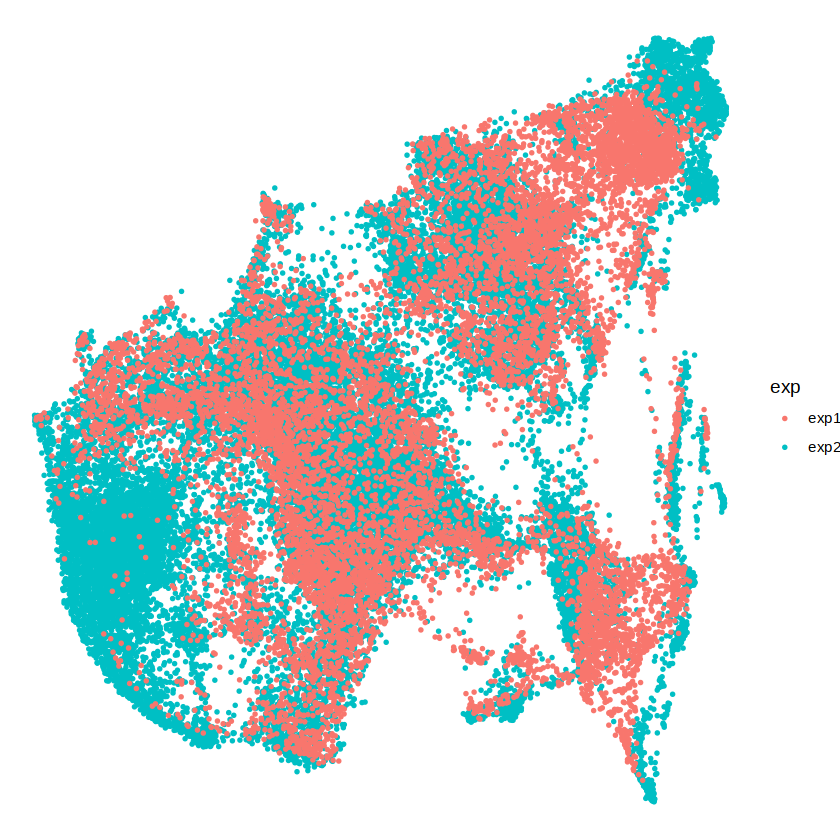

In [113]:
rna.seurat <- RunUMAP(rna.seurat, 
  dims = 1:args$rna_npcs,
  reduction = "pca",
  n.neighbors = 25,
  min.dist = 0.3,
  verbose=FALSE
)

# Fetch UMAP coordinates
umap.dt <- rna.seurat@reductions[["umap"]]@cell.embeddings %>% round(3) %>% as.data.table %>% 
  .[,cell:=colnames(rna.seurat)] %>%
  setnames(c("UMAP1","UMAP2","cell")) %>% 
  .[,c("cell","UMAP1","UMAP2")] %>%
  merge(.,metadata_rna, by='cell')

# Plot umap
ggplot(umap.dt, aes(UMAP1, UMAP2, col=exp)) + 
    geom_point(size=0.5) + 
    theme_void()


In [42]:
rna.seurat

An object of class Seurat 
19979 features across 38346 samples within 1 assay 
Active assay: RNA (19979 features, 0 variable features)
 2 dimensional reductions calculated: pca, umap

In [122]:
rna.seurat@assays$RNA@data = logcounts_regressed.mtx
rna.seurat <- FindVariableFeatures(rna.seurat, selection.method = 'vst', nfeatures = args$rna_nfeatures)
head(rna.seurat@assays$RNA@var.features, 200)

[1] "Hba-x"      "Hbb-bh1"    "Ctla2a"     "Mest"       "Ccdc163"   
  [6] "Ptcra"      "Xlr5a"      "Cfhr1"      "Dqx1"       "Igfbp5"    
 [11] "Ssc4d"      "Pkp1"       "Myh11"      "Asic4"      "Acpp"      
 [16] "Hapln1"     "Slc25a21"   "Adam2"      "Skap1"      "Retn"      
 [21] "Tas1r1"     "Ikzf3"      "Pde6c"      "Them7"      "Klhl1"     
 [26] "Casp8"      "Calcrl"     "Prkg1"      "Reln"       "Cntnap5a"  
 [31] "Edil3"      "Hba-a1"     "Asb18"      "Nrxn3"      "Cntnap5b"  
 [36] "Eya2"       "Kcnq5"      "Alpk2"      "Runx1"      "Flt1"      
 [41] "Sox6"       "Rsad1"      "Adgrl4"     "Spatc1"     "Ubash3a"   
 [46] "Vcan"       "Pkd1l2"     "Tek"        "Fli1"       "Rfx4"      
 [51] "Mecom"      "Fosb"       "Caly"       "Igf2"       "Entpd3"    
 [56] "Plxdc1"     "Tex21"      "Ptprm"      "Ebf1"       "Scnn1a"    
 [61] "Sgcd"       "Myo1h"      "Ror1"       "Rapgef5"    "Golga3"    
 [66] "Col1a1"     "Pdzrn4"     "Bmp6"       "Nckap5"     "Cdh5"      
 [71] "Adam12"     "Kirrel3"    "Gal"        "Pde7b"      "Camk1d"    
 [76] "Cubn"       "Exd2"       "Vav3"       "Dnaaf1"     "Kcnj3"     
 [81] "Sfrp1"      "Abca6"      "Csgalnact1" "Pacsin1"    "Dnaic2"    
 [86] "Bpifc"      "Ddb2"       "Gpm6b"      "Igf1"       "Col1a2"    
 [91] "Hnf4aos"    "S100a2"     "Nme5"       "Galnt18"    "Mrc1"      
 [96] "Ptprb"      "Nrg1"       "Erbb4"      "Nyap2"      "Ksr2"      
[101] "Ikzf1"      "Vegfc"      "Zfp652os"   "Cntn4"      "Actl6b"    
[106] "Mmrn2"      "Usp26"      "Atl1"       "Adap2os"    "Robo2"     
[111] "Ramp2"      "Alcam"      "Mt1"        "H19"        "Slit2"     
[116] "Airn"       "Ntm"        "Pecam1"     "Igfbp3"     "Dlk1"      
[121] "Mctp1"      "Lefty1"     "Trh"        "Kctd16"     "Chrm2"     
[126] "Thsd4"      "Zfpm2"      "Cldn5"      "Kdr"        "Ctla2b"    
[131] "Nxph1"      "Hyal4"      "Slc2a3"     "Ntng1"      "Ano3"      
[136] "Grik1"      "Col18a1"    "Odf4"       "Slc44a4"    "Nexmif"    
[141] "Mypop"      "Nedd9"      "Nfib"       "Gja4"       "Arhgap31"  
[146] "Dnah10"     "Cdkn1c"     "Mypn"       "Cadm2"      "Avil"      
[151] "Lrrc39"     "Tenm2"      "Ccdc141"    "Gsdmc4"     "Tbxas1"    
[156] "Nav3"       "Fkbp6"      "Gfod2"      "Pcdh17"     "Map1b"     
[161] "Mast4"      "Dach1"      "Folr2"      "Tbx4"       "Plpp3"     
[166] "Inpp5d"     "F2r"        "Tie1"       "Tmco4"      "Ikzf2"     
[171] "Lrp2"       "Btk"        "Ahnak"      "Col4a1"     "Rsph14"    
[176] "Rbms3"      "Aoah"       "Ptgds"      "Trpm5"      "Wee2"      
[181] "Kcnh7"      "Mef2c"      "Tmbim7"     "Arhgap6"    "Fbn2"      
[186] "Loxl1"      "Lsamp"      "Acoxl"      "Hbb-y"      "Flrt2"     
[191] "Ephb1"      "Styxl1"     "Exoc6"      "Ptpre"      "Mllt3"     
[196] "Col4a2"     "Plcl1"      "Ank1"       "Plac1"      "Rasgrp3"

In [123]:
rna.seurat@assays$RNA@data = tmp
rna.seurat <- FindVariableFeatures(rna.seurat, selection.method = 'vst', nfeatures = args$rna_nfeatures)
head(rna.seurat@assays$RNA@var.features, 200)

[1] "Hba-x"      "Hbb-bh1"    "Ctla2a"     "Mest"       "Ccdc163"   
  [6] "Ptcra"      "Xlr5a"      "Cfhr1"      "Dqx1"       "Igfbp5"    
 [11] "Ssc4d"      "Pkp1"       "Myh11"      "Asic4"      "Acpp"      
 [16] "Hapln1"     "Slc25a21"   "Adam2"      "Skap1"      "Retn"      
 [21] "Tas1r1"     "Ikzf3"      "Pde6c"      "Them7"      "Klhl1"     
 [26] "Casp8"      "Calcrl"     "Prkg1"      "Reln"       "Cntnap5a"  
 [31] "Edil3"      "Hba-a1"     "Asb18"      "Nrxn3"      "Cntnap5b"  
 [36] "Eya2"       "Kcnq5"      "Alpk2"      "Runx1"      "Flt1"      
 [41] "Sox6"       "Rsad1"      "Adgrl4"     "Spatc1"     "Ubash3a"   
 [46] "Vcan"       "Pkd1l2"     "Tek"        "Fli1"       "Rfx4"      
 [51] "Mecom"      "Fosb"       "Caly"       "Igf2"       "Entpd3"    
 [56] "Plxdc1"     "Tex21"      "Ptprm"      "Ebf1"       "Scnn1a"    
 [61] "Sgcd"       "Myo1h"      "Ror1"       "Rapgef5"    "Golga3"    
 [66] "Col1a1"     "Pdzrn4"     "Bmp6"       "Nckap5"     "Cdh5"      
 [71] "Adam12"     "Kirrel3"    "Gal"        "Pde7b"      "Camk1d"    
 [76] "Cubn"       "Exd2"       "Vav3"       "Dnaaf1"     "Kcnj3"     
 [81] "Sfrp1"      "Abca6"      "Csgalnact1" "Pacsin1"    "Dnaic2"    
 [86] "Bpifc"      "Ddb2"       "Gpm6b"      "Igf1"       "Col1a2"    
 [91] "Hnf4aos"    "S100a2"     "Nme5"       "Galnt18"    "Mrc1"      
 [96] "Ptprb"      "Nrg1"       "Erbb4"      "Nyap2"      "Ksr2"      
[101] "Ikzf1"      "Vegfc"      "Zfp652os"   "Cntn4"      "Actl6b"    
[106] "Mmrn2"      "Usp26"      "Atl1"       "Adap2os"    "Robo2"     
[111] "Ramp2"      "Alcam"      "Mt1"        "H19"        "Slit2"     
[116] "Airn"       "Ntm"        "Pecam1"     "Igfbp3"     "Dlk1"      
[121] "Mctp1"      "Lefty1"     "Trh"        "Kctd16"     "Chrm2"     
[126] "Thsd4"      "Zfpm2"      "Cldn5"      "Kdr"        "Ctla2b"    
[131] "Nxph1"      "Hyal4"      "Slc2a3"     "Ntng1"      "Ano3"      
[136] "Grik1"      "Col18a1"    "Odf4"       "Slc44a4"    "Nexmif"    
[141] "Mypop"      "Nedd9"      "Nfib"       "Gja4"       "Arhgap31"  
[146] "Dnah10"     "Cdkn1c"     "Mypn"       "Cadm2"      "Avil"      
[151] "Lrrc39"     "Tenm2"      "Ccdc141"    "Gsdmc4"     "Tbxas1"    
[156] "Nav3"       "Fkbp6"      "Gfod2"      "Pcdh17"     "Map1b"     
[161] "Mast4"      "Dach1"      "Folr2"      "Tbx4"       "Plpp3"     
[166] "Inpp5d"     "F2r"        "Tie1"       "Tmco4"      "Ikzf2"     
[171] "Lrp2"       "Btk"        "Ahnak"      "Col4a1"     "Rsph14"    
[176] "Rbms3"      "Aoah"       "Ptgds"      "Trpm5"      "Wee2"      
[181] "Kcnh7"      "Mef2c"      "Tmbim7"     "Arhgap6"    "Fbn2"      
[186] "Loxl1"      "Lsamp"      "Acoxl"      "Hbb-y"      "Flrt2"     
[191] "Ephb1"      "Styxl1"     "Exoc6"      "Ptpre"      "Mllt3"     
[196] "Col4a2"     "Plcl1"      "Ank1"       "Plac1"      "Rasgrp3"

In [150]:
logcounts(rna.sce) = logcounts_regressed.mtx
rna.seurat = as.Seurat(rna.sce)

In [152]:
rna.seurat <- FindVariableFeatures(rna.seurat, selection.method = 'vst', nfeatures = args$rna_nfeatures)

In [153]:
head(rna.seurat@assays$RNA@meta.features)

,vst.mean,vst.variance,vst.variance.expected,vst.variance.standardized,vst.variable
,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
Xkr4,0.998357065,7.33010553,1.86081789,3.9391848,TRUE
Rp1,0.008449382,0.01161201,0.01127329,1.0300464,FALSE
Sox17,0.057241955,0.09240720,0.08251385,1.1198992,TRUE
Mrpl15,1.209904553,1.77054318,2.40461997,0.7363089,FALSE
Lypla1,0.577478746,0.84319496,0.95065491,0.8869622,FALSE
Tcea1,1.895921348,3.66059779,4.50937310,0.8117753,FALSE


In [156]:
logcounts(rna.sce)[1,] = 0 

In [158]:
#logcounts(rna.sce) = tmp 
rna.seurat = as.Seurat(rna.sce)
rna.seurat <- FindVariableFeatures(rna.seurat, selection.method = 'vst', nfeatures = args$rna_nfeatures)
head(rna.seurat@assays$RNA@meta.features)

,vst.mean,vst.variance,vst.variance.expected,vst.variance.standardized,vst.variable
,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
Xkr4,0.998357065,7.33010553,1.86081789,3.9391848,TRUE
Rp1,0.008449382,0.01161201,0.01127329,1.0300464,FALSE
Sox17,0.057241955,0.09240720,0.08251385,1.1198992,TRUE
Mrpl15,1.209904553,1.77054318,2.40461997,0.7363089,FALSE
Lypla1,0.577478746,0.84319496,0.95065491,0.8869622,FALSE
Tcea1,1.895921348,3.66059779,4.50937310,0.8117753,FALSE


Warning message:
“Hmm... 3 active multicore processes were detected, but without any active multicore futures (it is not clear by what mechanism they were created). Because of this, the 'future' package do not know how to resolve/collect them and will therefore treat them as they do not exist.”
Warning message:
“Hmm... 3 active multicore processes were detected, but without any active multicore futures (it is not clear by what mechanism they were created). Because of this, the 'future' package do not know how to resolve/collect them and will therefore treat them as they do not exist.”


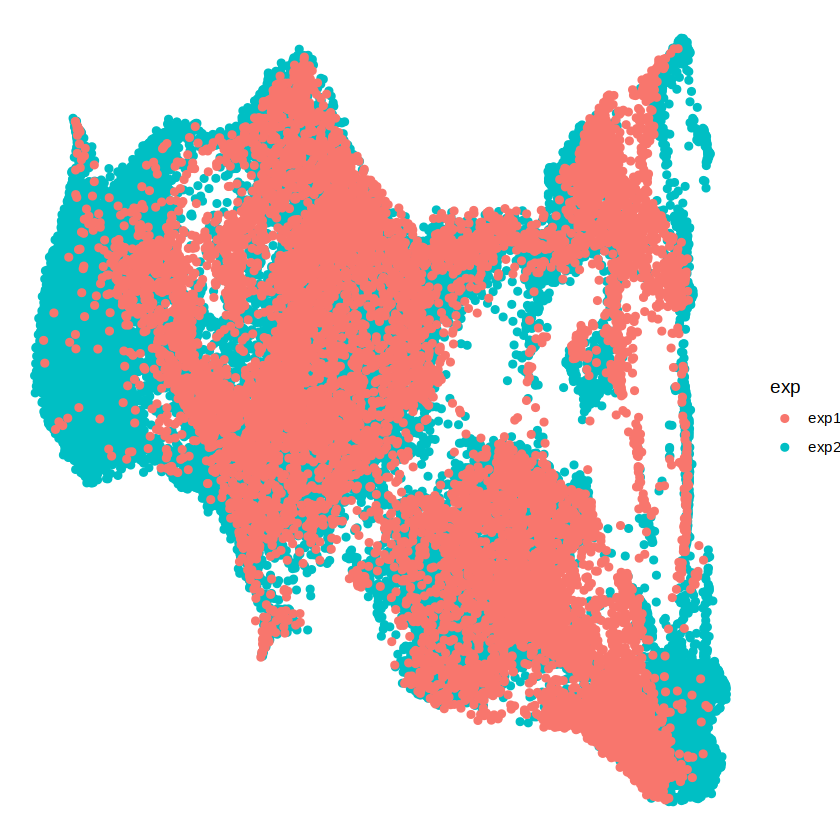

In [ ]:
rna.seurat@assays$RNA@data = logcounts_regressed.mtx
rna.seurat <- FindVariableFeatures(rna.seurat, selection.method = 'vst', nfeatures = args$rna_nfeatures)
rna.seurat@assays$RNA@data = tmp
rna.seurat <- ScaleData(rna.seurat, 
                    features = VariableFeatures(rna.seurat),
                    vars.to.regress = args$vars_to_regress,
                    verbose = FALSE)

rna.seurat <- RunPCA(rna.seurat, features = VariableFeatures(rna.seurat), npcs = args$rna_npcs, verbose = FALSE)

rna.seurat <- RunUMAP(rna.seurat, 
  dims = 1:args$rna_npcs,
  reduction = "pca",
  n.neighbors = 25,
  min.dist = 0.3,
  verbose=FALSE
)

# Fetch UMAP coordinates
umap.dt <- rna.seurat@reductions[["umap"]]@cell.embeddings %>% round(3) %>% as.data.table %>% 
  .[,cell:=colnames(rna.seurat)] %>%
  setnames(c("UMAP1","UMAP2","cell")) %>% 
  .[,c("cell","UMAP1","UMAP2")] %>%
  merge(.,metadata_rna, by='cell')

# Plot umap
ggplot(umap.dt, aes(UMAP1, UMAP2, col=exp)) + 
    geom_point() + 
    theme_void()


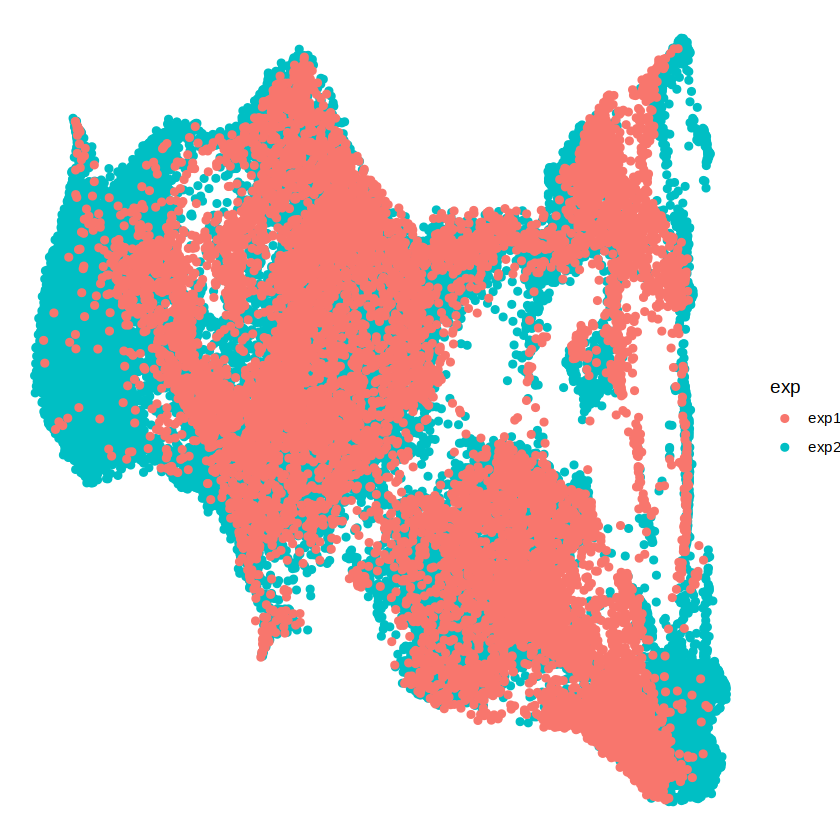

In [47]:

rna.seurat <- FindVariableFeatures(rna.seurat, selection.method = 'vst', nfeatures = args$rna_nfeatures)

rna.seurat <- ScaleData(rna.seurat, 
                    features = VariableFeatures(rna.seurat),
                    vars.to.regress = args$vars_to_regress,
                    verbose = FALSE)

rna.seurat <- RunPCA(rna.seurat, features = VariableFeatures(rna.seurat), npcs = args$rna_npcs, verbose = FALSE)

rna.seurat <- RunUMAP(rna.seurat, 
  dims = 1:args$rna_npcs,
  reduction = "pca",
  n.neighbors = 25,
  min.dist = 0.3,
  verbose=FALSE
)

# Fetch UMAP coordinates
umap.dt <- rna.seurat@reductions[["umap"]]@cell.embeddings %>% round(3) %>% as.data.table %>% 
  .[,cell:=colnames(rna.seurat)] %>%
  setnames(c("UMAP1","UMAP2","cell")) %>% 
  .[,c("cell","UMAP1","UMAP2")] %>%
  merge(.,metadata_rna, by='cell')

# Plot umap
ggplot(umap.dt, aes(UMAP1, UMAP2, col=exp)) + 
    geom_point() + 
    theme_void()


# Feature selection & PCA based on regressed log counts outside of seurat


In [159]:
logcounts(rna.sce) = logcounts_regressed.mtx

# Feature selection based on regressed log counts
rna_features <- modelGeneVar(rna.sce, block=metadata_rna$exp) %>% as.data.table(keep.rownames = T) %>%
  setnames("rn","gene") %>%
  .[mean>=0.001] %>% setorder(FDR) %>% head(args$rna_nfeatures) %>% .$gene

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [160]:
sce_filt = rna.sce[rna_features,]

In [161]:
sce_filt

class: SingleCellExperiment 
dim: 4000 38346 
metadata(0):
assays(2): counts logcounts
rownames(4000): Ube2w Klf7 ... Clcn2 Ncstn
rowData names(0):
colnames(38346): 1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1
  1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1 ...
  rv_eo_deg_day4_dtag#TTTGTGTTCATTTGTC-1
  rv_eo_deg_day4_dtag#TTTGTTGGTACTTAGG-1
colData names(13): barcode sample ... doublet_call exp
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [162]:
  sce_filt <- runPCA(sce_filt, ncomponents = args$rna_npcs, ntop=args$rna_nfeatures)

In [163]:
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = 25, min_dist = 0.3)


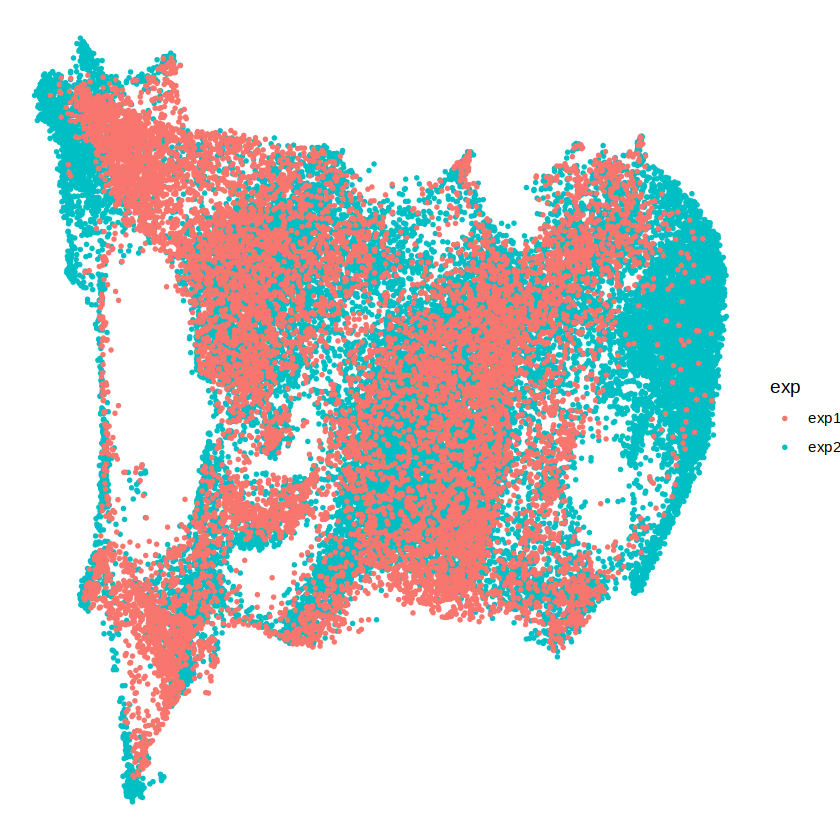

In [164]:
# Fetch UMAP coordinates
umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell"))%>%
  merge(.,metadata_rna, by='cell')

# Plot umap
ggplot(umap.dt, aes(UMAP1, UMAP2, col=exp)) + 
    geom_point(size=0.5) + 
    theme_void()


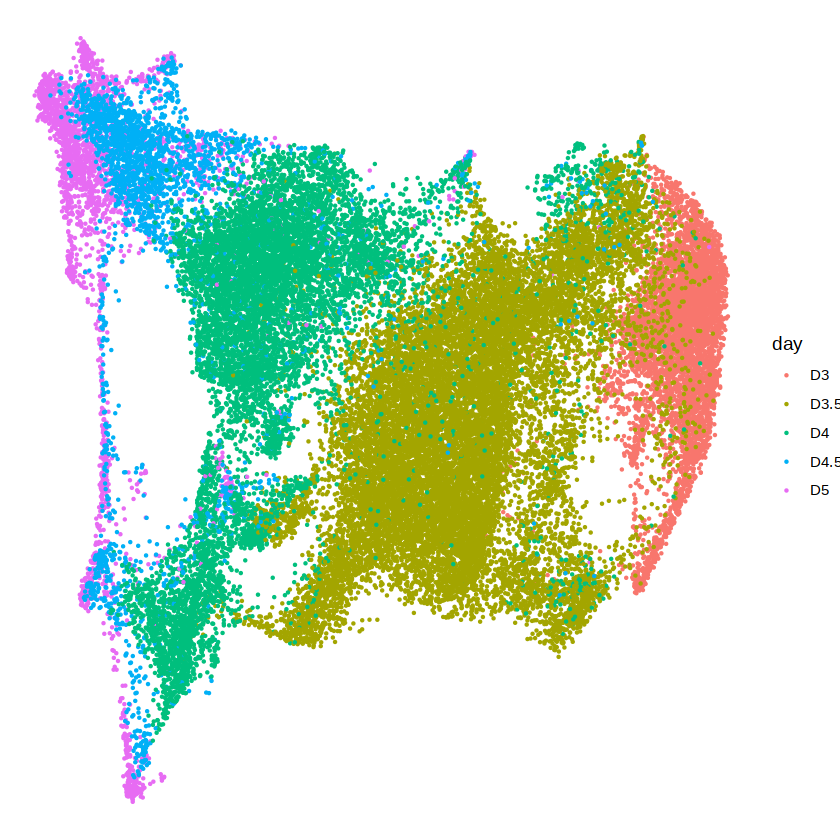

In [166]:
# Plot umap
ggplot(umap.dt, aes(UMAP1, UMAP2, col=day)) + 
    geom_point(size=0.2) + 
    theme_void()


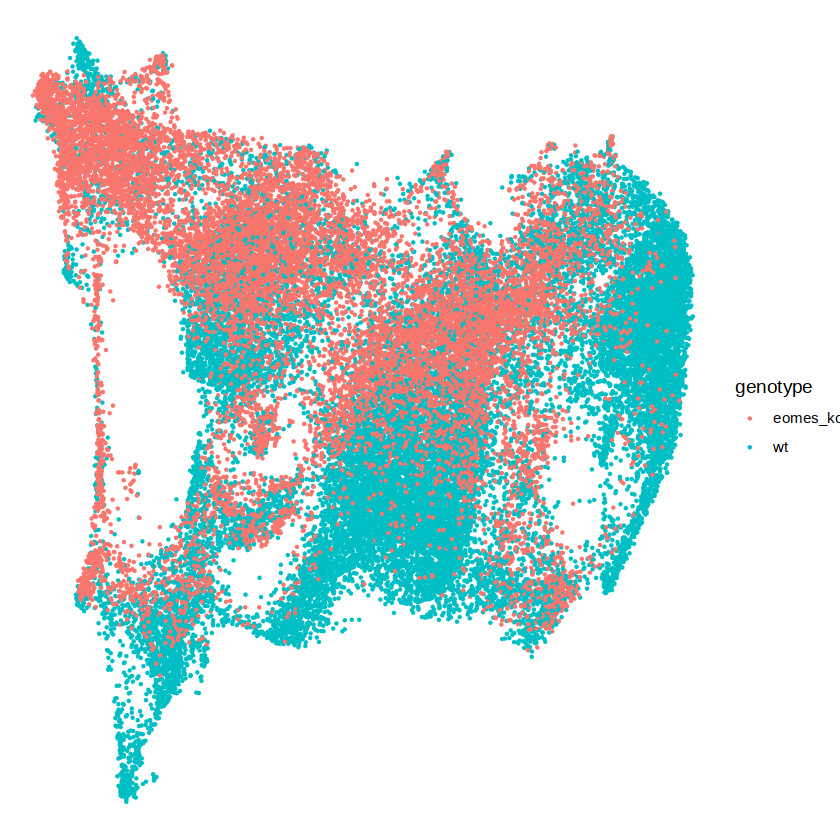

In [167]:
# Plot umap
ggplot(umap.dt, aes(UMAP1, UMAP2, col=genotype)) + 
    geom_point(size=0.2) + 
    theme_void()


In [168]:
logcounts(rna.sce) = logcounts_regressed.mtx

# Feature selection based on regressed log counts
rna_features <- modelGeneVar(rna.sce, block=metadata_rna$exp) %>% as.data.table(keep.rownames = T) %>%
  setnames("rn","gene") %>%
  .[mean>=0.001] %>% setorder(FDR) %>% head(args$rna_nfeatures) %>% .$gene

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [169]:
sce_filt = rna.sce[rna_features,]

In [170]:
sce_filt

class: SingleCellExperiment 
dim: 4000 38346 
metadata(0):
assays(2): counts logcounts
rownames(4000): Ube2w Klf7 ... Clcn2 Ncstn
rowData names(0):
colnames(38346): 1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1
  1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1 ...
  rv_eo_deg_day4_dtag#TTTGTGTTCATTTGTC-1
  rv_eo_deg_day4_dtag#TTTGTTGGTACTTAGG-1
colData names(13): barcode sample ... doublet_call exp
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [171]:
  sce_filt <- runPCA(sce_filt, ncomponents = args$rna_npcs, ntop=args$rna_nfeatures, scale = TRUE)

In [172]:
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = 25, min_dist = 0.3)


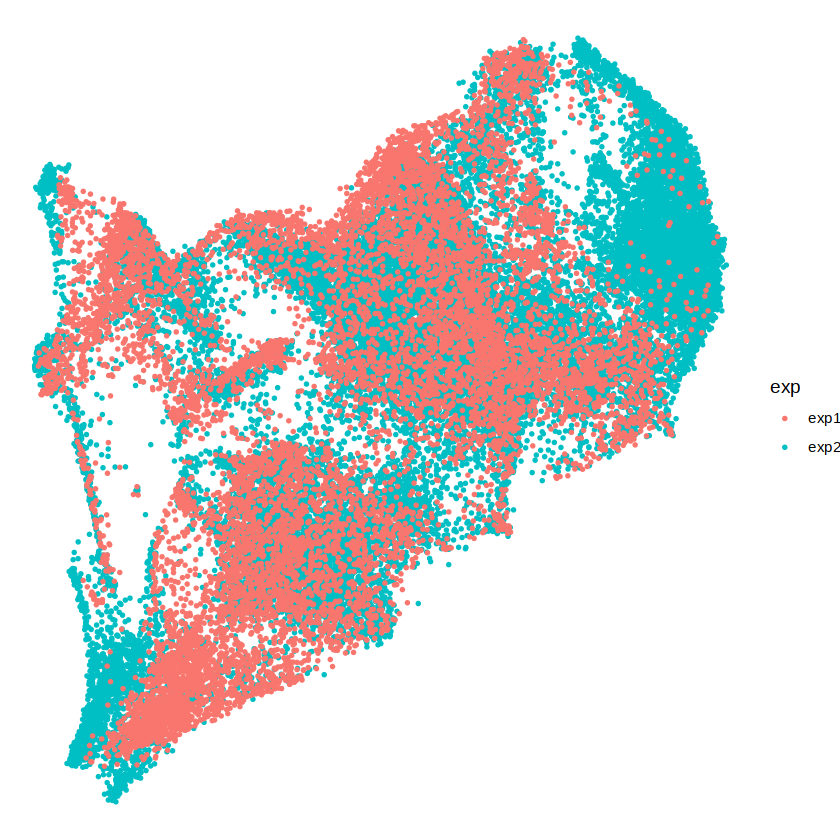

In [173]:
# Fetch UMAP coordinates
umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell"))%>%
  merge(.,metadata_rna, by='cell')

# Plot umap
ggplot(umap.dt, aes(UMAP1, UMAP2, col=exp)) + 
    geom_point(size=0.5) + 
    theme_void()


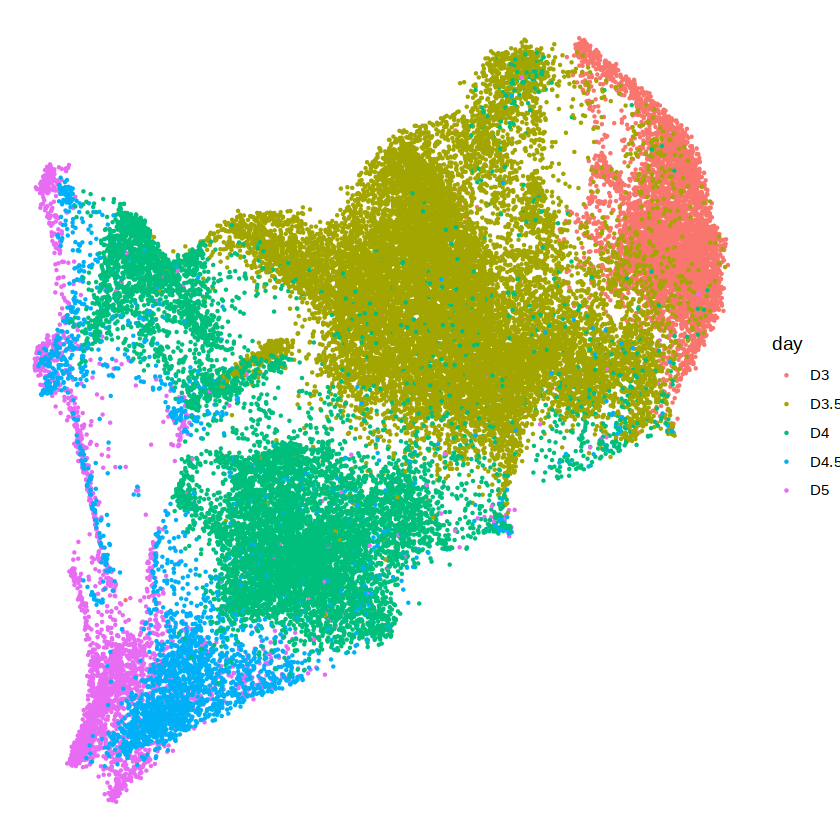

In [174]:
# Plot umap
ggplot(umap.dt, aes(UMAP1, UMAP2, col=day)) + 
    geom_point(size=0.2) + 
    theme_void()


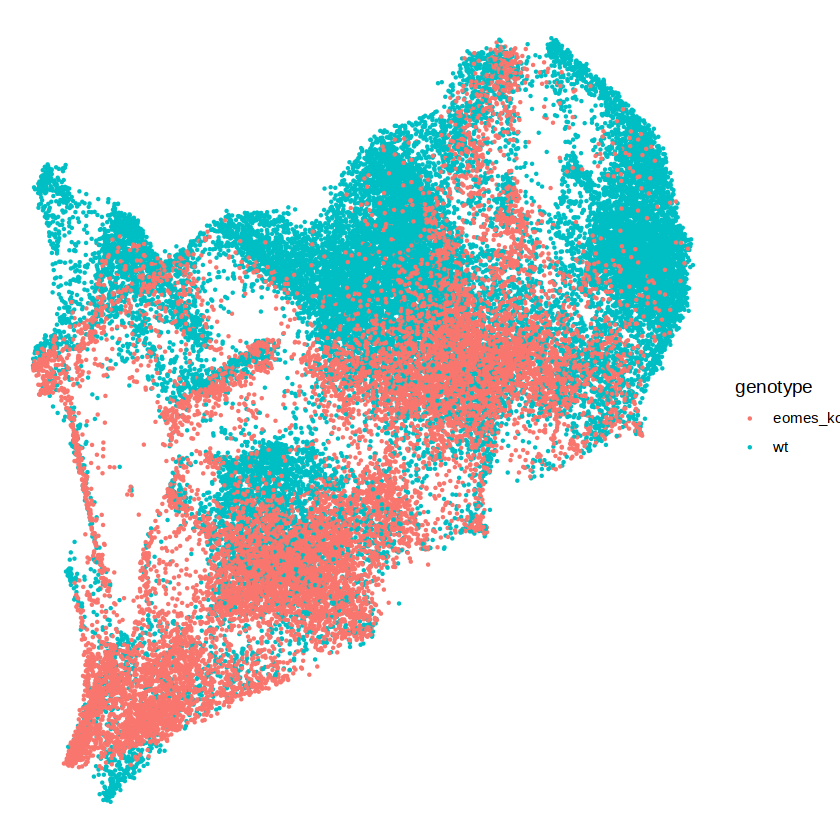

In [175]:
# Plot umap
ggplot(umap.dt, aes(UMAP1, UMAP2, col=genotype)) + 
    geom_point(size=0.2) + 
    theme_void()
